# Notebook 04 — EDA: Operational Data

**Mục tiêu**: Phân tích tình trạng vận hành
- **Shipments**: Tốc độ giao hàng, tỉ lệ giao đúng hạn
- **Returns**: Tỉ lệ trả hàng, lý do trả
- **Reviews**: Phân phối điểm đánh giá, sentiment
- **Inventory**: Tồn kho theo sản phẩm, tình trạng out-of-stock

In [4]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_processed
from pathlib import Path
from src.plot_utils import save_operations

sns.set_theme(style='whitegrid', palette='Purples_r')
%matplotlib inline

In [5]:
shipments = load_processed('shipments_clean.csv')
returns   = load_processed('returns_clean.csv')
reviews   = load_processed('reviews_clean.csv')
inventory = load_processed('inventory_clean.csv')
orders    = load_processed('orders_clean.csv')
customers = load_processed('customers_clean.csv')
geography = load_processed('geography_clean.csv')
order_items = load_processed('order_items_clean.csv')
products = load_processed('products_clean.csv')

d:\Code\DS_Code\revenue_forecast_ecommerce\notebooks\..\src\data_loader.py:40: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(PROCESSED / subfolder / filename)


## 1. Vận chuyển (Shipments)

**Chỉ số cần phân tích**:
- On-time delivery rate (%)
- Thời gian giao hàng trung bình (ngày)
- Phân bổ theo carrier/đơn vị vận chuyển

Mean delivery_days: 4.50
Median delivery_days: 4
P90 delivery_days: 7
Mean order_to_delivery_days: 6.00


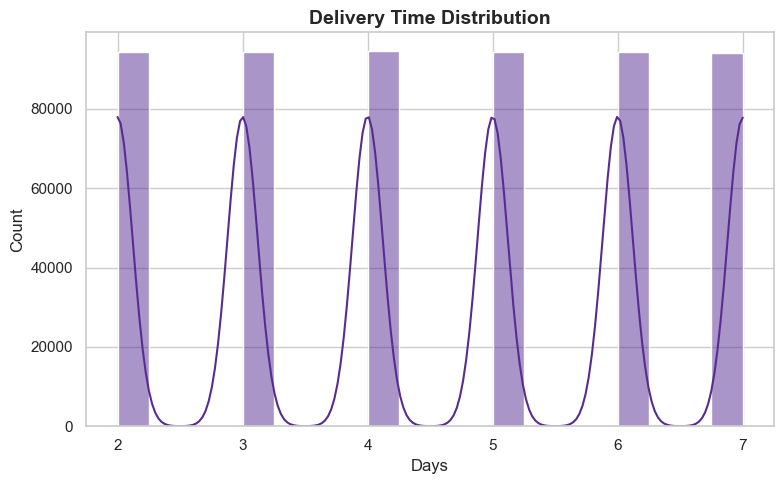

In [6]:
import sys
sys.path.append('..')

# 1) Calculate delivery time in days
ship = shipments.copy()
ship['ship_date'] = pd.to_datetime(ship['ship_date'])
ship['delivery_date'] = pd.to_datetime(ship['delivery_date'])
ship['delivery_days'] = (ship['delivery_date'] - ship['ship_date']).dt.days

orders['order_date'] = pd.to_datetime(orders['order_date'])
ship = ship.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
ship['order_to_delivery_days'] = (ship['delivery_date'] - ship['order_date']).dt.days


print(f"Mean delivery_days: {ship['delivery_days'].mean():.2f}")
print(f"Median delivery_days: {ship['delivery_days'].median():.0f}")
print(f"P90 delivery_days: {ship['delivery_days'].quantile(0.9):.0f}")
print(f"Mean order_to_delivery_days: {ship['order_to_delivery_days'].mean():.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(ship['delivery_days'], bins=20, kde=True)
plt.title('Delivery Time Distribution', fontsize=14, weight='bold')
plt.xlabel('Days')
plt.tight_layout()
save_operations('delivery_time_distribution')
plt.show()

**Nhận xét:** Đơn hàng trung bình mất khoảng 4.5 ngày để giao, đa số giao trong 4 ngày và 90% giao trong tối đa 7 ngày. => Không phải vấn đề về thời gian giao hàng, vì thời gian ship chỉ trong vòng 1 tuần.

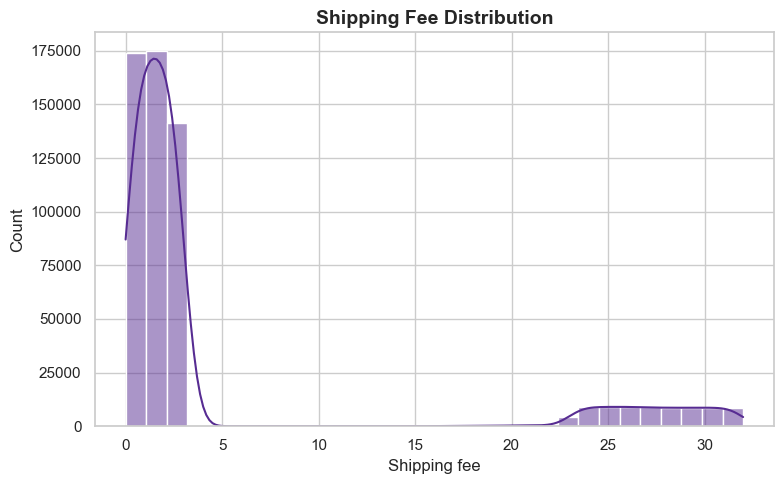

In [7]:
# 2) Shipping fee distribution
plt.figure(figsize=(8, 5))
sns.histplot(ship['shipping_fee'], bins=30, kde=True)
plt.title('Shipping Fee Distribution', fontsize=14, weight='bold')
plt.xlabel('Shipping fee')
plt.tight_layout()
save_operations('shipping_fee_distribution')
plt.show()

**Nhận xét:** Phí vận chuyển trung vị 1.73, P90 = 25.09; đa số đơn phí thấp, một số ít đơn phí rất cao.

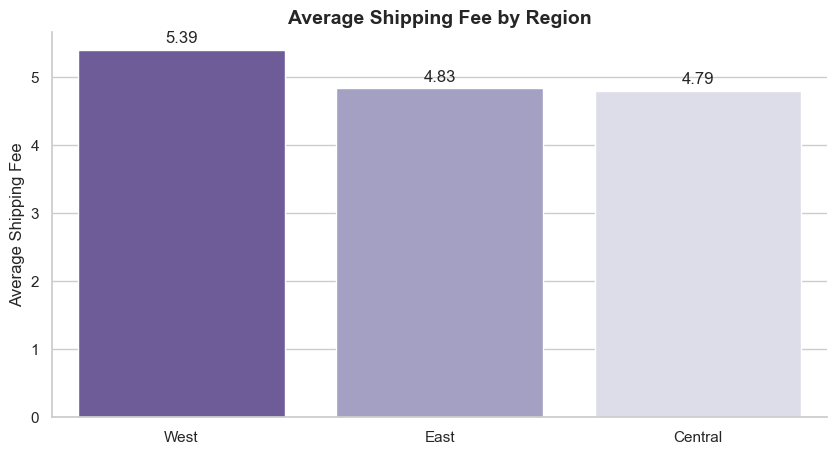

In [8]:
# 3) Average shipping fee by region
ship_region = (
    shipments[['order_id', 'shipping_fee']]
    .merge(
        orders[['order_id', 'zip']],
        on='order_id',
        how='left'
    )
    .merge(
        geography[['zip', 'region']],
        on='zip',
        how='left'
    )
)

# Average shipping fee by region
avg_shipping_region = (
    ship_region
    .groupby('region', as_index=False)
    .agg(avg_shipping_fee=('shipping_fee', 'mean'))
    .sort_values('avg_shipping_fee', ascending=False)
)

plt.figure(figsize=(10, 5))

colors = sns.color_palette(
    'Purples_r',
    len(avg_shipping_region)
)

ax = sns.barplot(
    data=avg_shipping_region,
    x='region',
    y='avg_shipping_fee',
    palette=colors,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.title(
    'Average Shipping Fee by Region',
    fontsize=14,
    weight='bold'
)

plt.xlabel('')
plt.ylabel('Average Shipping Fee')

sns.despine()

save_operations('avg_shipping_fee_by_region')

plt.show()

## 2. Trả hàng (Returns)

**Chỉ số cần phân tích**:
- Return rate tổng thể (%)
- Lý do trả hàng phổ biến
- Return rate theo category sản phẩm

Return rate: 5.57%


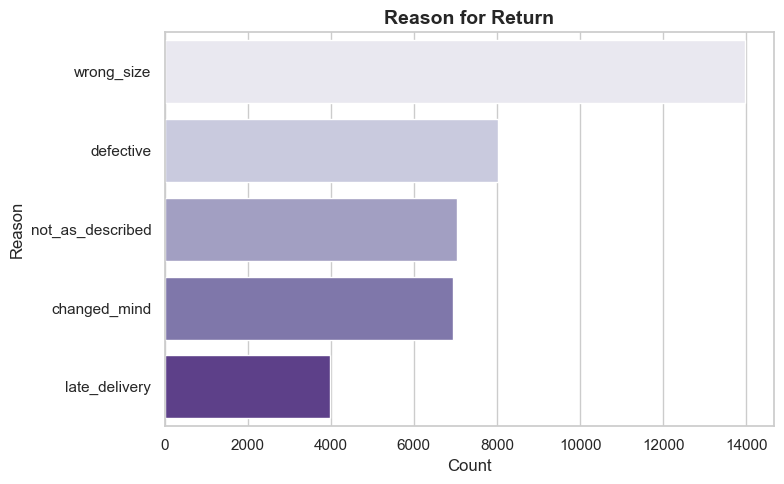

In [9]:
# 4) Reason for return
ret = returns.copy()
ret['return_date'] = pd.to_datetime(ret['return_date'])
reason_counts = ret['return_reason'].value_counts()

total_orders = orders['order_id'].nunique()
return_rate = ret['order_id'].nunique() / total_orders * 100
print(f"Return rate: {return_rate:.2f}%")

plt.figure(figsize=(8, 5))
sns.barplot(x=reason_counts.values, y=reason_counts.index, orient='h', palette='Purples')
plt.title('Reason for Return', fontsize=14, weight='bold')
plt.xlabel('Count')
plt.ylabel('Reason')
plt.tight_layout()
save_operations('return_reasons')
plt.show()

**Nhận xét:** Lý do trả hàng nhiều nhất là wrong_size (4,556 đơn), các lý do còn lại thấp hơn đáng kể. Công ty hoạt động ổn, tỷ lệ trả hàng chỉ có 5.57%. Nhưng, cần điều tra kỹ sao sai kích cỡ là lý do phổ biến nhất, có phải đến từ **sự thiếu đa dạng size**?

C:\Users\PC\AppData\Local\Temp\ipykernel_22384\698434511.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(ret['refund_amount'], bins=30, kde=True, palette='Purples')


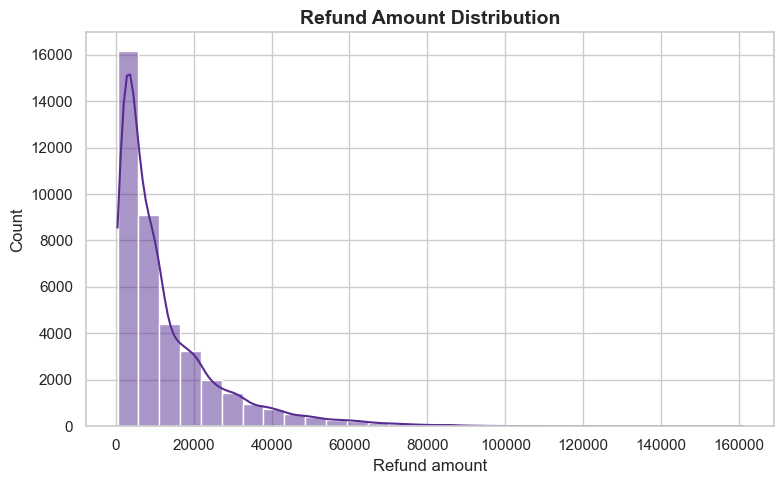

In [10]:
# 5) Refund amount distribution
plt.figure(figsize=(8, 5))
sns.histplot(ret['refund_amount'], bins=30, kde=True, palette='Purples')
plt.title('Refund Amount Distribution', fontsize=14, weight='bold')
plt.xlabel('Refund amount')
plt.tight_layout()
save_operations('refund_amount_distribution')
plt.show()

**Nhận xét:** Giá trị hoàn tiền trung vị 7,888.88; P90 = 30,910.35, cho thấy một nhóm nhỏ hoàn tiền rất cao. => Giá trị đơn hàng cao hay đây là nhóm khách hàng VIP chưa thỏa mãn với đơn hàng?

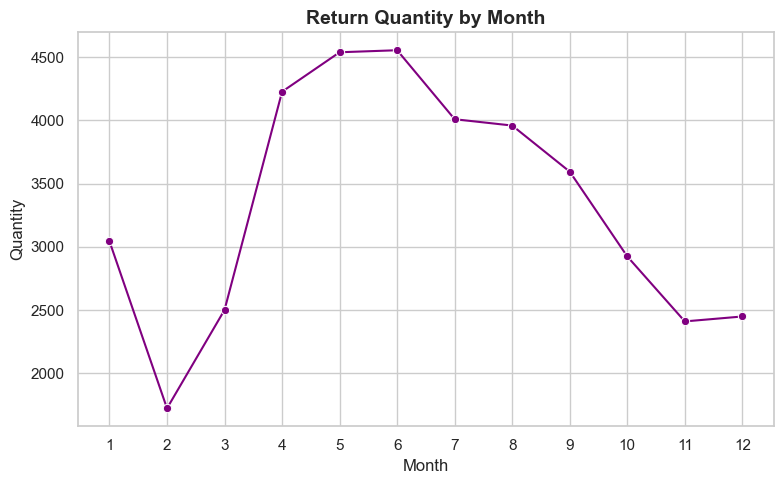

In [11]:
# 6) Returns by month (ignore year)
ret_month = ret['return_date'].dt.month.value_counts().sort_index()
month_labels = [str(m) for m in ret_month.index]
plt.figure(figsize=(8, 5))
sns.lineplot(x=month_labels, y=ret_month.values, marker='o', color='purple')
plt.title('Return Quantity by Month', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.tight_layout()
save_operations('returns_by_month')
plt.show()

**Nhận xét:** Return rate 5.57% (tính trên tổng đơn). Trả hàng nhiều nhất tháng 6 (4,556), thấp nhất tháng 2 (1,722).

## 3. Đánh giá (Reviews)

**Chỉ số cần phân tích**:
- Phân phối điểm đánh giá (1-5 sao)
- Rating trung bình theo category
- Xu hướng rating theo thời gian

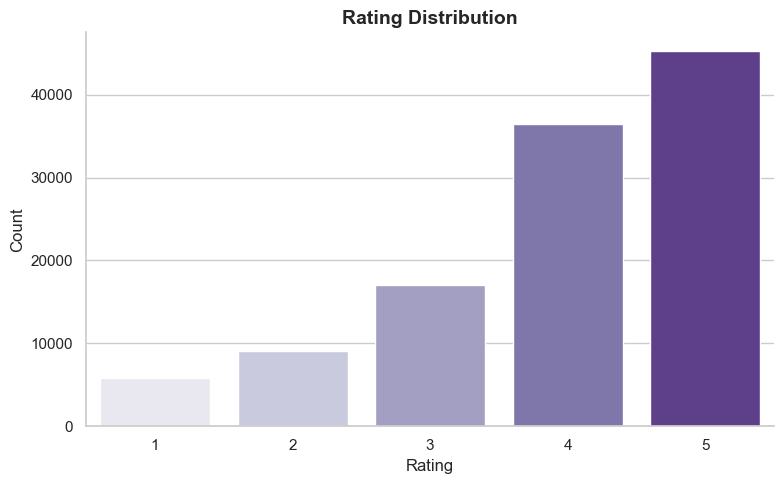

In [12]:
# 1) Rating distribution
rev = reviews.copy()
rev['review_date'] = pd.to_datetime(rev['review_date'])

plt.figure(figsize=(8, 5))

palette = sns.color_palette(
    "Purples",
    rev['rating'].nunique()
)

sns.countplot(
    data=rev,
    x='rating',
    palette=palette
)

plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')

sns.despine()

plt.tight_layout()
save_operations('rating_distribution')
plt.show()

**Nhận xét:** 5 sao chiếm 39.86%, 4 sao 32.07%; điểm trung bình 3.94, phản ánh mức hài lòng khá tốt.

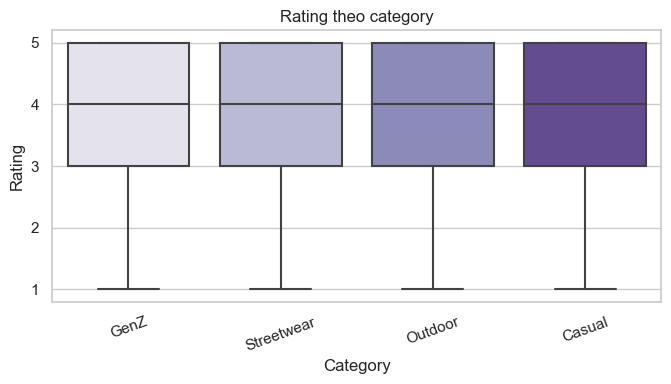

In [13]:
# 2) Rating by category
rev_cat = (
    rev
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)

plt.figure(figsize=(7, 4))
sns.boxplot(data=rev_cat, x='category', y='rating', palette='Purples')
plt.title('Rating theo category')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=20)
plt.tight_layout()
save_operations('rating_by_category')
plt.show()


**Nhận xét:** Rating cao nhất ở Streetwear (3.94) và thấp nhất ở GenZ (3.92); chênh lệch nhỏ.

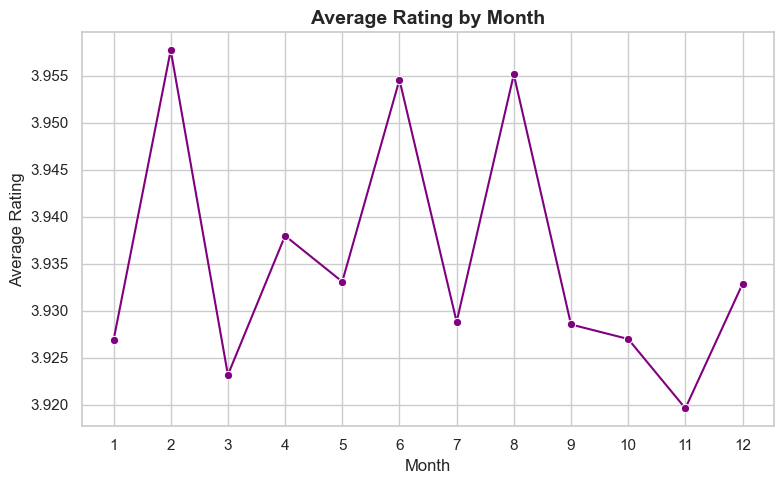

In [14]:
# 3) Avg rating by month
rev_month = rev.groupby(rev['review_date'].dt.month)['rating'].mean().sort_index()
month_labels = [str(m) for m in rev_month.index]
plt.figure(figsize=(8, 5))
sns.lineplot(x=month_labels, y=rev_month.values, marker='o', color='purple')
plt.title('Average Rating by Month', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.tight_layout()
save_operations('average_rating_by_month')
plt.show()

**Nhận xét:** Rating trung bình cao nhất tháng 2 (3.96), thấp nhất tháng 11 (3.92).

## 4. Tồn kho (Inventory)

**Chỉ số cần phân tích**:
- Số lượng tồn kho theo sản phẩm/category
- Tỉ lệ out-of-stock
- Stock turnover rate

Stock median: 62
Stock P90: 532


C:\Users\PC\AppData\Local\Temp\ipykernel_22384\708951756.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(inv['stock_on_hand'], bins=30, kde=True, palette='purple_r')


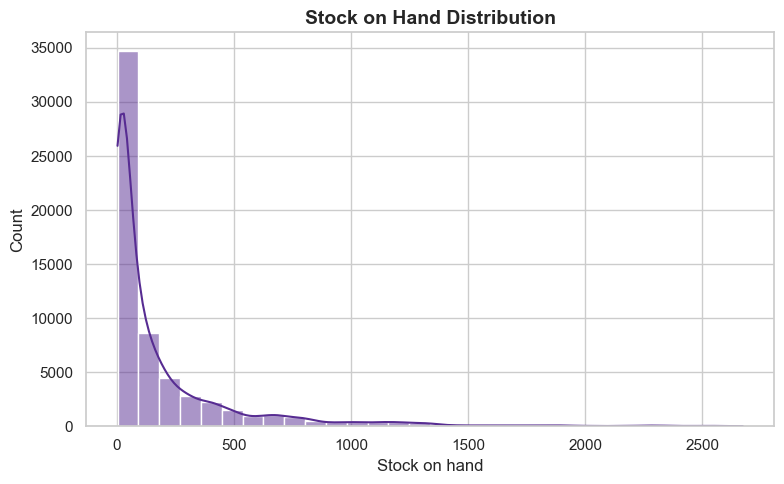

In [15]:
# 1) Stock on hand distribution
inv = inventory.copy()
stock_desc = inv['stock_on_hand'].describe(percentiles=[0.5, 0.9])
print(f"Stock median: {stock_desc['50%']:.0f}")
print(f"Stock P90: {stock_desc['90%']:.0f}")

plt.figure(figsize=(8, 5))
sns.histplot(inv['stock_on_hand'], bins=30, kde=True, palette='purple_r')
plt.title('Stock on Hand Distribution', fontsize=14, weight='bold')
plt.xlabel('Stock on hand')
plt.tight_layout()
save_operations('stock_on_hand_distribution')
plt.show()

**Nhận xét:** Tồn kho trung vị 62, P90 = 532; phân bố lệch phải, một số sản phẩm tồn rất cao.

Stockout rate by category:


category
GenZ          0.682927
Outdoor       0.673492
Streetwear    0.673211
Casual        0.662004
Name: stockout_flag, dtype: float64

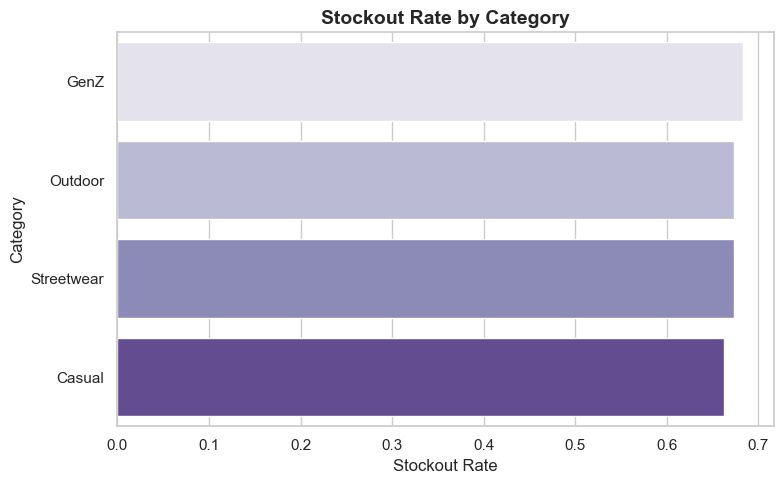

In [16]:
# 2) Stockout rate by category
stockout_rate = inv.groupby('category')['stockout_flag'].mean().sort_values(ascending=False)
print('Stockout rate by category:')
display(stockout_rate)

plt.figure(figsize=(8, 5))
sns.barplot(x=stockout_rate.values, y=stockout_rate.index, orient='h', palette='Purples')
plt.title('Stockout Rate by Category', fontsize=14, weight='bold')
plt.xlabel('Stockout Rate')
plt.ylabel('Category')
plt.tight_layout()
save_operations('stockout_rate_by_category')
plt.show()

**Nhận xét:** Tỉ lệ hết hàng cao nhất ở GenZ (68.29%), thấp nhất ở Casual (66.20%); chênh lệch nhỏ nhưng vẫn cao. => GenZ có ít sản phẩm nhất, nhưng tỷ lệ cháy hàng lại nhanh nhất => Liệu công ty có đang bỏ quan sản phẩm tiềm năng là GenZ không?

Max month: 11 (avg 198.23)
Min month: 8 (avg 180.67)


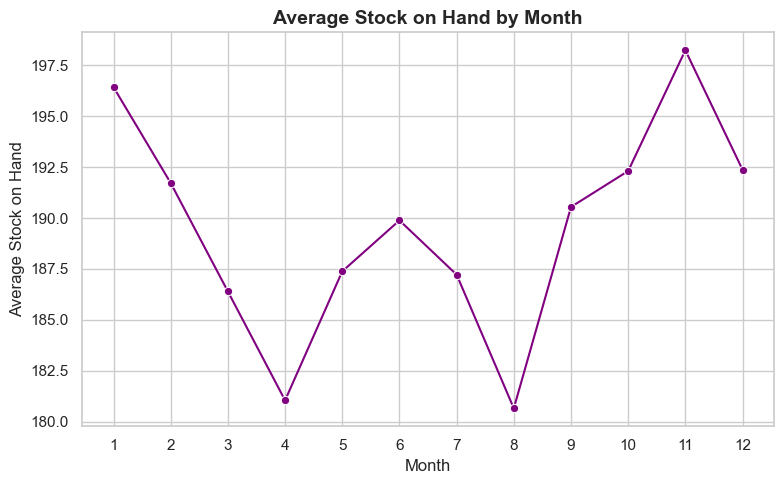

In [17]:
# 3) Avgrage stock on hand by month (ignore year)
inv_month = inv.groupby('month')['stock_on_hand'].mean().sort_index()
print(f"Max month: {inv_month.idxmax()} (avg {inv_month.max():.2f})")
print(f"Min month: {inv_month.idxmin()} (avg {inv_month.min():.2f})")
month_labels = [str(m) for m in inv_month.index]
plt.figure(figsize=(8, 5))
sns.lineplot(x=month_labels, y=inv_month.values, marker='o', color='purple')
plt.title('Average Stock on Hand by Month', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.ylabel('Average Stock on Hand')
plt.tight_layout()
save_operations('average_stock_by_month')
plt.show()

**Nhận xét:** Tồn kho trung bình cao nhất tháng 11 (~198.23), thấp nhất tháng 8 (~180.67).

## 5. Tổng kết


MONTHLY TRENDS DATA


,shipments,returns,avg_stock,revenue
month,,,,
1.0,27910,3044,196.0,5.955858e+08
2.0,30148,1722,192.0,7.087285e+08
3.0,46777,2501,186.0,1.224311e+09
4.0,65555,4228,181.0,1.516494e+09
5.0,64399,4540,187.0,1.406139e+09
6.0,64010,4556,190.0,1.601538e+09
7.0,55571,4010,187.0,1.374268e+09
8.0,56824,3960,181.0,1.386175e+09
9.0,45085,3595,191.0,1.090516e+09


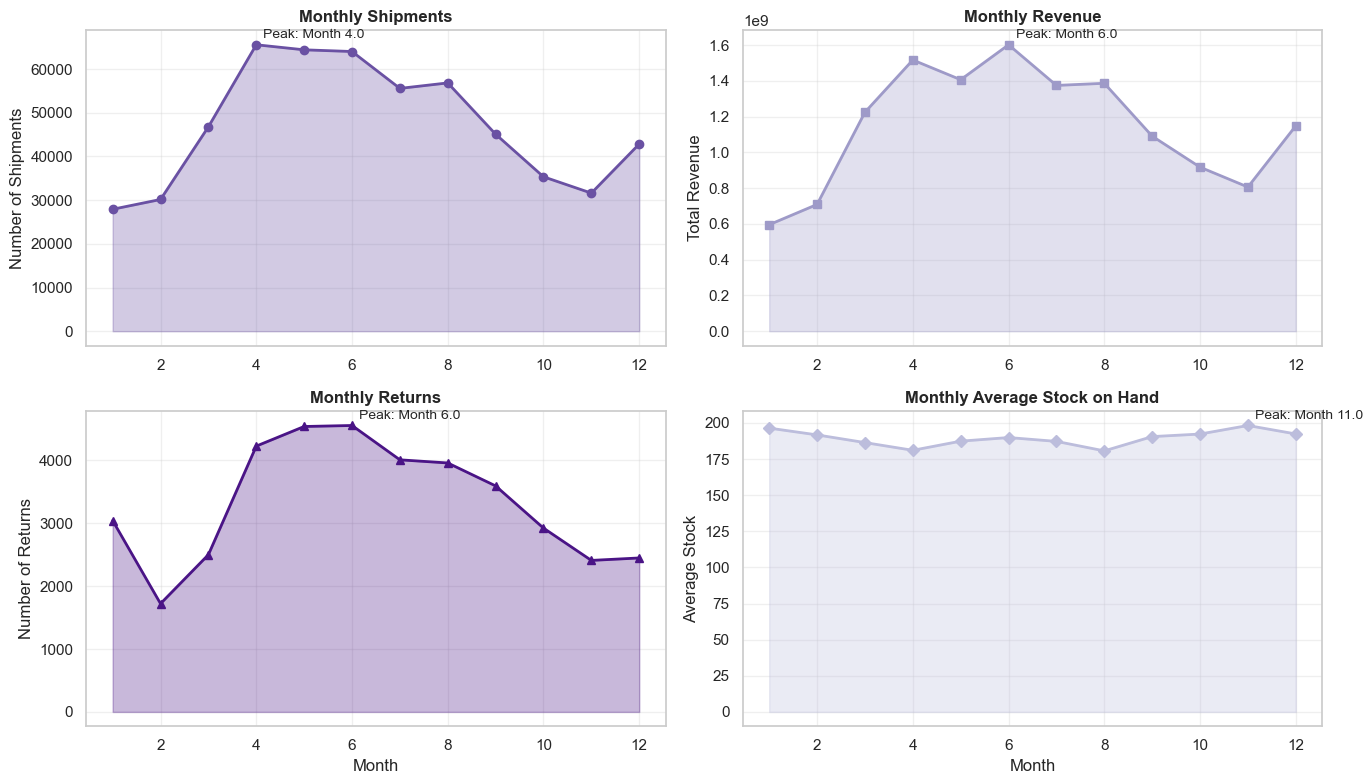


MONTHLY PATTERN ANALYSIS
Stock peaks at:      Month 11.0 (avg stock = 198)
Revenue peaks at:    Month 6.0 (revenue = 1601537996)
Shipments peak at:   Month 4.0 (shipments = 65555)
Returns peak at:     Month 6.0 (returns = 4556)

Potential Pattern:
  Month 11.0: Stock accumulates
  Month 6.0: Strong sales period
  Month 4.0: Peak shipping (possibly from prior sales)
  Month 6.0: Returns increase


In [18]:
# Goal: Find pattern like Stock peak tháng 11 -> Sales peak tháng 12-1 -> Ship tháng 4?

# Prepare order_revenue if not already created
if 'order_revenue' not in dir():
    order_revenue = (
        order_items
        .merge(orders[['order_id', 'zip']], on='order_id', how='left')
        .merge(geography[['zip', 'region']], on='zip', how='left')
    )
    order_revenue['revenue'] = (
        order_revenue['quantity'] * order_revenue['unit_price'] - 
        order_revenue['discount_amount'].fillna(0)
    )

# A) Monthly shipments
monthly_shipments = (
    shipments
    .assign(month=pd.to_datetime(shipments['ship_date']).dt.month)
    .groupby('month')
    .size()
    .rename('shipments')
)

# B) Monthly returns
monthly_returns = (
    returns
    .assign(month=pd.to_datetime(returns['return_date']).dt.month)
    .groupby('month')
    .size()
    .rename('returns')
)

# C) Monthly inventory (average stock on hand)
monthly_inventory = (
    inventory
    .groupby('month')['stock_on_hand']
    .mean()
    .rename('avg_stock')
)

# D) Monthly revenue (sum of order item revenue)
monthly_revenue = (
    order_revenue
    .assign(month=pd.to_datetime(orders['order_date']).dt.month)
    .groupby('month')
    .agg({'revenue': 'sum'})
    .squeeze()
    .rename('revenue')
)

# Combine all metrics
monthly_metrics = pd.DataFrame({
    'shipments': monthly_shipments,
    'returns': monthly_returns,
    'avg_stock': monthly_inventory,
    'revenue': monthly_revenue
}).fillna(0)

print("\n" + "=" * 60)
print("MONTHLY TRENDS DATA")
print("=" * 60)
display(monthly_metrics.round(0))

# 6.2.2) Plot 4 metrics in a grid
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Row 1: Shipments and Revenue
axes[0, 0].plot(monthly_metrics.index, monthly_metrics['shipments'], marker='o', linewidth=2, color='#6a51a3')
axes[0, 0].fill_between(monthly_metrics.index, monthly_metrics['shipments'], alpha=0.3, color='#6a51a3')
axes[0, 0].set_title('Monthly Shipments', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Shipments')
axes[0, 0].grid(True, alpha=0.3)
peak_ship = monthly_metrics['shipments'].idxmax()
axes[0, 0].annotate(f'Peak: Month {peak_ship}', 
                     xy=(peak_ship, monthly_metrics['shipments'].max()),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)

axes[0, 1].plot(monthly_metrics.index, monthly_metrics['revenue'], marker='s', linewidth=2, color='#9e9ac8')
axes[0, 1].fill_between(monthly_metrics.index, monthly_metrics['revenue'], alpha=0.3, color='#9e9ac8')
axes[0, 1].set_title('Monthly Revenue', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Revenue')
axes[0, 1].grid(True, alpha=0.3)
peak_rev = monthly_metrics['revenue'].idxmax()
axes[0, 1].annotate(f'Peak: Month {peak_rev}', 
                     xy=(peak_rev, monthly_metrics['revenue'].max()),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)

# Row 2: Returns and Inventory
axes[1, 0].plot(monthly_metrics.index, monthly_metrics['returns'], marker='^', linewidth=2, color='#4a1486')
axes[1, 0].fill_between(monthly_metrics.index, monthly_metrics['returns'], alpha=0.3, color='#4a1486')
axes[1, 0].set_title('Monthly Returns', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Returns')
axes[1, 0].grid(True, alpha=0.3)
peak_ret = monthly_metrics['returns'].idxmax()
axes[1, 0].annotate(f'Peak: Month {peak_ret}', 
                     xy=(peak_ret, monthly_metrics['returns'].max()),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)

axes[1, 1].plot(monthly_metrics.index, monthly_metrics['avg_stock'], marker='D', linewidth=2, color='#bcbddc')
axes[1, 1].fill_between(monthly_metrics.index, monthly_metrics['avg_stock'], alpha=0.3, color='#bcbddc')
axes[1, 1].set_title('Monthly Average Stock on Hand', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Stock')
axes[1, 1].grid(True, alpha=0.3)
peak_stock = monthly_metrics['avg_stock'].idxmax()
axes[1, 1].annotate(f'Peak: Month {peak_stock}', 
                     xy=(peak_stock, monthly_metrics['avg_stock'].max()),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
save_operations('monthly_trends_grid')
plt.show()

print("\n" + "=" * 60)
print("MONTHLY PATTERN ANALYSIS")
print("=" * 60)
print(f"Stock peaks at:      Month {peak_stock} (avg stock = {monthly_metrics['avg_stock'].max():.0f})")
print(f"Revenue peaks at:    Month {peak_rev} (revenue = {monthly_metrics['revenue'].max():.0f})")
print(f"Shipments peak at:   Month {peak_ship} (shipments = {monthly_metrics['shipments'].max():.0f})")
print(f"Returns peak at:     Month {peak_ret} (returns = {monthly_metrics['returns'].max():.0f})")
print("\nPotential Pattern:")
print(f"  Month {peak_stock}: Stock accumulates")
print(f"  Month {peak_rev}: Strong sales period")
print(f"  Month {peak_ship}: Peak shipping (possibly from prior sales)")
print(f"  Month {peak_ret}: Returns increase")

Phân tích đồng thời bốn chỉ số vận hành gồm **tồn kho, doanh thu, giao hàng và trả hàng** cho thấy doanh nghiệp có tính mùa vụ tương đối rõ rệt. Trong năm, **shipments đạt đỉnh vào tháng 4**, trong khi **revenue và returns cùng đạt đỉnh vào tháng 6**. Bên cạnh đó, **tồn kho trung bình đạt mức cao nhất vào tháng 11**, phản ánh hoạt động tích trữ hàng hóa trước các giai đoạn nhu cầu cao.



LAG ANALYSIS: Stock → Sales Relationship

Correlation: Stock → Revenue (with lag)
  Lag 0 (same month):      -0.765
  Lag 1 (stock leads):   -0.716
  Lag 2 (stock leads):   -0.543

Correlation: Revenue → Shipments (with lag)
  Lag 0 (same month):       0.974
  Lag 1 (revenue leads): 0.978
  Lag 2 (revenue leads): 0.959


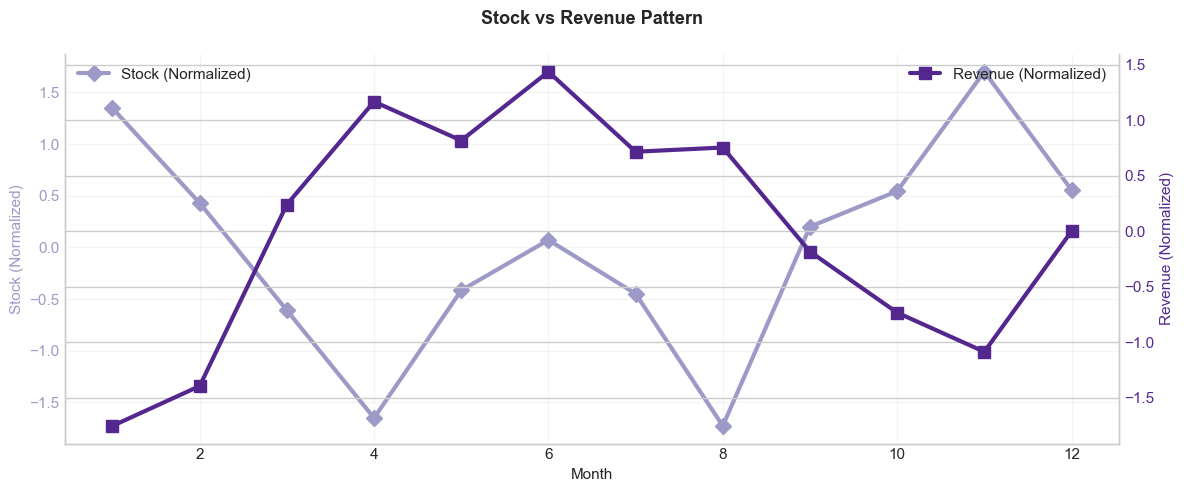

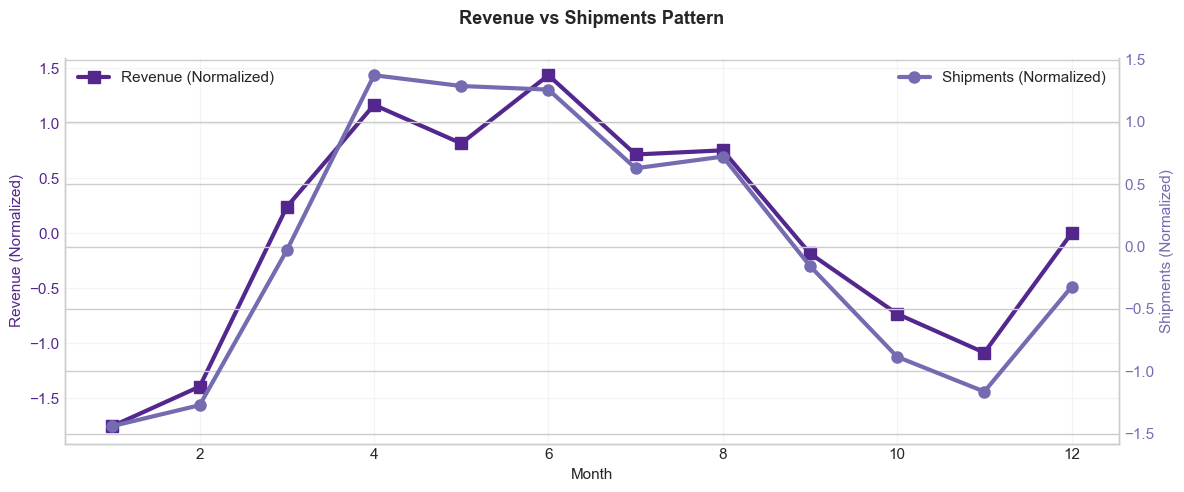

In [19]:
print("\n" + "=" * 60)
print("LAG ANALYSIS: Stock → Sales Relationship")
print("=" * 60)

# ==========================================================
# Normalize metrics
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

normalized_metrics = pd.DataFrame(
    scaler.fit_transform(
        monthly_metrics[
            ['avg_stock', 'revenue', 'shipments', 'returns']
        ]
    ),
    columns=[
        'stock_norm',
        'revenue_norm',
        'shipments_norm',
        'returns_norm'
    ],
    index=monthly_metrics.index
)

# ==========================================================
# Correlation Analysis
# ==========================================================

print("\nCorrelation: Stock → Revenue (with lag)")

for lag in [0, 1, 2]:

    if lag == 0:
        corr = (
            normalized_metrics['stock_norm']
            .corr(normalized_metrics['revenue_norm'])
        )

        print(
            f"  Lag 0 (same month):      {corr:.3f}"
        )

    else:
        corr = (
            normalized_metrics['stock_norm']
            .iloc[:-lag]
            .corr(
                normalized_metrics['revenue_norm']
                .iloc[lag:]
            )
        )

        print(
            f"  Lag {lag} (stock leads):   {corr:.3f}"
        )

print("\nCorrelation: Revenue → Shipments (with lag)")

for lag in [0, 1, 2]:

    if lag == 0:
        corr = (
            normalized_metrics['revenue_norm']
            .corr(normalized_metrics['shipments_norm'])
        )

        print(
            f"  Lag 0 (same month):       {corr:.3f}"
        )

    else:
        corr = (
            normalized_metrics['revenue_norm']
            .iloc[:-lag]
            .corr(
                normalized_metrics['shipments_norm']
                .iloc[lag:]
            )
        )

        print(
            f"  Lag {lag} (revenue leads): {corr:.3f}"
        )

# ==========================================================
# Purple Theme
# ==========================================================

dark_purple = '#54278f'
medium_purple = '#756bb1'
light_purple = '#9e9ac8'
very_light_purple = '#cbc9e2'

plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================================
# 6.3.1 Stock vs Revenue
# ==========================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

# Stock
ax1.plot(
    monthly_metrics.index,
    normalized_metrics['stock_norm'],
    marker='D',
    linewidth=3,
    color=light_purple,
    label='Stock (Normalized)',
    markersize=8
)

ax1.set_xlabel(
    'Month',
    fontsize=11
)

ax1.set_ylabel(
    'Stock (Normalized)',
    fontsize=11,
    color=light_purple
)

ax1.tick_params(
    axis='y',
    labelcolor=light_purple
)

ax1.grid(
    True,
    alpha=0.2
)

ax1.spines['top'].set_visible(False)

# Revenue
ax2 = ax1.twinx()

ax2.plot(
    monthly_metrics.index,
    normalized_metrics['revenue_norm'],
    marker='s',
    linewidth=3,
    color=dark_purple,
    label='Revenue (Normalized)',
    markersize=8
)

ax2.set_ylabel(
    'Revenue (Normalized)',
    fontsize=11,
    color=dark_purple
)

ax2.tick_params(
    axis='y',
    labelcolor=dark_purple
)

ax2.spines['top'].set_visible(False)

fig.suptitle(
    'Stock vs Revenue Pattern',
    fontsize=13,
    fontweight='bold'
)

ax1.legend(
    loc='upper left'
)

ax2.legend(
    loc='upper right'
)

plt.tight_layout()

save_operations('stock_vs_revenue_overlay')
plt.show()

# ==========================================================
# 6.3.2 Revenue vs Shipments
# ==========================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

# Revenue
ax1.plot(
    monthly_metrics.index,
    normalized_metrics['revenue_norm'],
    marker='s',
    linewidth=3,
    color=dark_purple,
    label='Revenue (Normalized)',
    markersize=8
)

ax1.set_xlabel(
    'Month',
    fontsize=11
)

ax1.set_ylabel(
    'Revenue (Normalized)',
    fontsize=11,
    color=dark_purple
)

ax1.tick_params(
    axis='y',
    labelcolor=dark_purple
)

ax1.grid(
    True,
    alpha=0.2
)

ax1.spines['top'].set_visible(False)

# Shipments
ax2 = ax1.twinx()

ax2.plot(
    monthly_metrics.index,
    normalized_metrics['shipments_norm'],
    marker='o',
    linewidth=3,
    color=medium_purple,
    label='Shipments (Normalized)',
    markersize=8
)

ax2.set_ylabel(
    'Shipments (Normalized)',
    fontsize=11,
    color=medium_purple
)

ax2.tick_params(
    axis='y',
    labelcolor=medium_purple
)

ax2.spines['top'].set_visible(False)

fig.suptitle(
    'Revenue vs Shipments Pattern',
    fontsize=13,
    fontweight='bold'
)

ax1.legend(
    loc='upper left'
)

ax2.legend(
    loc='upper right'
)

plt.tight_layout()

save_operations('revenue_vs_shipments_overlay')

plt.show()

**Doanh thu và số lượng giao hàng** có xu hướng biến động cùng chiều trong phần lớn thời gian, cho thấy hoạt động vận hành nhìn chung đang đáp ứng tốt nhu cầu thị trường. Tuy nhiên, **số lượng trả hàng cũng tăng mạnh trong giai đoạn doanh thu đạt đỉnh**, cho thấy tăng trưởng doanh thu đi kèm với áp lực về chất lượng đơn hàng hoặc mức độ phù hợp của sản phẩm.

Trong khi đó, **tồn kho chỉ dao động trong phạm vi tương đối hẹp so với doanh thu**, cho thấy hiệu quả kinh doanh có thể chịu ảnh hưởng nhiều hơn từ **nhu cầu thị trường, hiệu quả bán hàng và cơ cấu sản phẩm** hơn là từ quy mô tồn kho đơn thuần. Nhìn chung, doanh nghiệp đang vận hành theo **một chu kỳ mùa vụ rõ ràng** và cần tập trung kiểm soát **nguyên nhân trả hàng** để cải thiện **doanh thu thực nhận**.